In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pde
from pde import CartesianGrid, ScalarField, FieldCollection

In [2]:
# =========================================================
# 1. PARAMETERS
# =========================================================
hbar = 1.0
m = 1.0
V0 = 4.0           # barrier height
a = 2.0            # barrier width
eps = 0.15         # smoothing width for the barrier

L = 10.0           # computational domain [-L, L]
N = 512            # number of grid points

k = 2.0
omega = hbar * k**2 / (2 * m)   # free-particle dispersion

# absorbing sponge near the right boundary
sigma0 = 2.0
x_sponge = 7.0

# time stepping
dt = 1e-3
t_final = 4.0
n_steps = int(t_final / dt)

# save every few steps for plotting/animation later if needed
save_every = 200

# =========================================================
# 2. GRID
# =========================================================
grid = CartesianGrid([(-L, L)], [N])
x = grid.axes_coords[0]

In [3]:
# =========================================================
# 2. GRID
# =========================================================
grid = CartesianGrid([(-L, L)], [N])
x = grid.axes_coords[0]

In [4]:
# =========================================================
# 3. SMOOTHED POTENTIAL BARRIER
#    V_eps(x) = V0/2 [tanh(x/eps) - tanh((x-a)/eps)]
# =========================================================
def smooth_barrier(x, V0, a, eps):
    return 0.5 * V0 * (np.tanh(x / eps) - np.tanh((x - a) / eps))

Vx = smooth_barrier(x, V0, a, eps)
V_field = ScalarField(grid, data=Vx)

In [6]:
# =========================================================
# 4. ABSORBING SPONGE FUNCTION
# =========================================================
def sponge_profile(x, x_sponge, L, sigma0):
    sigma = np.zeros_like(x)
    mask = x > x_sponge
    sigma[mask] = sigma0 * ((x[mask] - x_sponge) / (L - x_sponge))**2
    return sigma

sigma_x = sponge_profile(x, x_sponge, L, sigma0)
sigma_field = ScalarField(grid, data=sigma_x)

In [7]:
# =========================================================
# 5. INITIAL CONDITION
#    psi(x,0) = psi0(x) = exp(i k x) * exp(-(x-x0)^2/s^2)
#    split into u and v:
#    u = Re(psi), v = Im(psi)
# =========================================================
x0 = -6.0
s = 0.8

gaussian = np.exp(-((x - x0)**2) / s**2)
u0 = np.cos(k * x) * gaussian
v0 = np.sin(k * x) * gaussian

u = ScalarField(grid, data=u0, label="u")
v = ScalarField(grid, data=v0, label="v")

state = FieldCollection([u, v], labels=["u", "v"])

In [8]:
# =========================================================
# 6. TIME-DEPENDENT LEFT BOUNDARY CONDITION
#    psi(-L,t) = exp(i(k(-L)-omega t))
#    so
#    u(-L,t) = cos(k(-L)-omega t)
#    v(-L,t) = sin(k(-L)-omega t)
#
#    RIGHT SIDE:
#    We use derivative = 0 plus the sponge layer.
#    This is simpler than coding the fully coupled Robin BC.
# =========================================================
def boundary_conditions(t, k, omega, L):
    theta = k * (-L) - omega * t

    bc_u = {
        "x-": {"value": np.cos(theta)},
        "x+": {"derivative": 0}
    }

    bc_v = {
        "x-": {"value": np.sin(theta)},
        "x+": {"derivative": 0}
    }

    return bc_u, bc_v


In [9]:
# =========================================================
# 7. RHS OF THE SPLIT SCHRODINGER SYSTEM
#
#    From psi = u + i v:
#
#    u_t = -(hbar/(2m)) v_xx + (V/hbar) v - sigma(x) u
#    v_t =  (hbar/(2m)) u_xx - (V/hbar) u - sigma(x) v
# =========================================================
def compute_rhs(u, v, t, hbar, m, V_field, sigma_field, k, omega, L):
    bc_u, bc_v = boundary_conditions(t, k, omega, L)

    u_xx = u.laplace(bc=bc_u)
    v_xx = v.laplace(bc=bc_v)

    du_dt = -(hbar / (2 * m)) * v_xx + (V_field / hbar) * v - sigma_field * u
    dv_dt =  (hbar / (2 * m)) * u_xx - (V_field / hbar) * u - sigma_field * v

    return du_dt, dv_dt

In [10]:
# =========================================================
# 8. RK4 TIME STEPPING
#    (more stable than forward Euler)
# =========================================================
def rk4_step(u, v, t, dt, hbar, m, V_field, sigma_field, k, omega, L):
    k1u, k1v = compute_rhs(u, v, t, hbar, m, V_field, sigma_field, k, omega, L)

    u2 = u + 0.5 * dt * k1u
    v2 = v + 0.5 * dt * k1v
    k2u, k2v = compute_rhs(u2, v2, t + 0.5 * dt, hbar, m, V_field, sigma_field, k, omega, L)

    u3 = u + 0.5 * dt * k2u
    v3 = v + 0.5 * dt * k2v
    k3u, k3v = compute_rhs(u3, v3, t + 0.5 * dt, hbar, m, V_field, sigma_field, k, omega, L)

    u4 = u + dt * k3u
    v4 = v + dt * k3v
    k4u, k4v = compute_rhs(u4, v4, t + dt, hbar, m, V_field, sigma_field, k, omega, L)

    u_new = u + (dt / 6.0) * (k1u + 2 * k2u + 2 * k3u + k4u)
    v_new = v + (dt / 6.0) * (k1v + 2 * k2v + 2 * k3v + k4v)

    return u_new, v_new


In [11]:
# =========================================================
# 9. TIME LOOP
# =========================================================
times = [0.0]
saved_u = [u.data.copy()]
saved_v = [v.data.copy()]

t = 0.0
for step in range(n_steps):
    u, v = rk4_step(u, v, t, dt, hbar, m, V_field, sigma_field, k, omega, L)
    t += dt

    if step % save_every == 0:
        times.append(t)
        saved_u.append(u.data.copy())
        saved_v.append(v.data.copy())

In [12]:
# =========================================================
# 10. FINAL PROBABILITY DENSITY
#     |psi|^2 = u^2 + v^2
# =========================================================
psi_sq_initial = u0**2 + v0**2
psi_sq_final = u.data**2 + v.data**2

# =========================================================
# 11. TRANSMISSION PROBABILITY
#     T(a) ≈ ∫_{x>a} |psi(x,t_final)|^2 dx
# =========================================================
mask_trans = x > a
T = np.trapz(psi_sq_final[mask_trans], x[mask_trans])

print(f"Transmission probability T(a={a:.3f}) = {T:.6f}")

Transmission probability T(a=2.000) = 0.296805


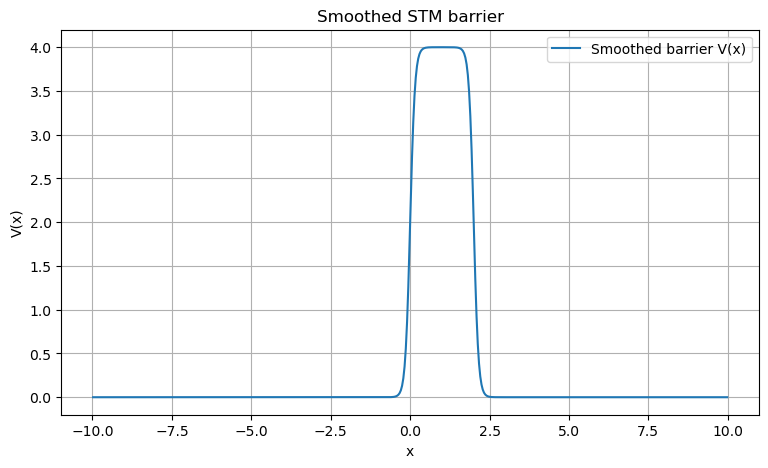

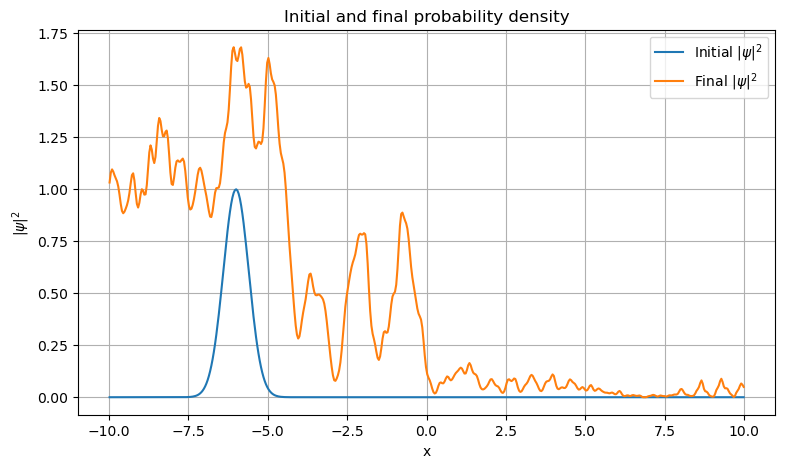

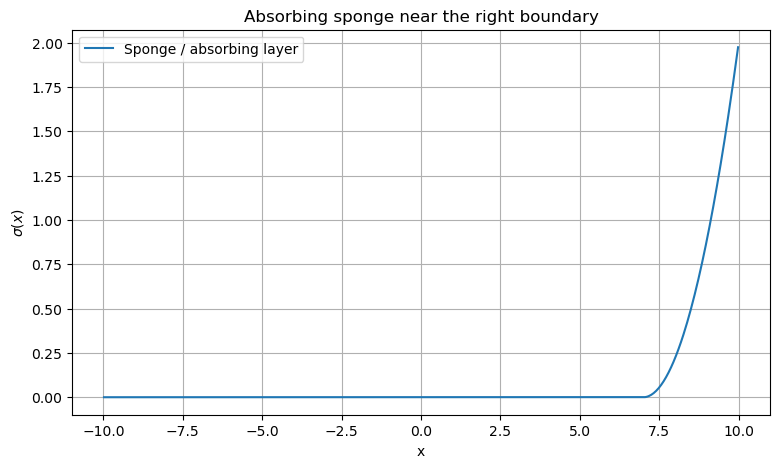

In [13]:
# =========================================================
# 12. PLOTS
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(x, Vx, label="Smoothed barrier V(x)")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Smoothed STM barrier")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(x, psi_sq_initial, label=r"Initial $|\psi|^2$")
plt.plot(x, psi_sq_final, label=r"Final $|\psi|^2$")
plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.title("Initial and final probability density")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(x, sigma_x, label="Sponge / absorbing layer")
plt.xlabel("x")
plt.ylabel(r"$\sigma(x)$")
plt.title("Absorbing sponge near the right boundary")
plt.grid(True)
plt.legend()
plt.show()